# Project Overview & Objective

**Objective:**
The goal of this project is to build a Machine Learning model that forecasts the AC Power output of a solar power plant based on weather sensor readings (such as solar irradiance and temperature). In a real-world trading environment like ENGIE, accurate power forecasting is essential to optimise power grid integration and maximise trading revenues on the energy market.

**Steps:**
1. **Data Loading & Alignment:** Merge power generation data with weather sensor data.

2. **Exploratory Data Analysis (EDA):** Check for missing values, data types, and understand the distributions.

3. **Data Visualization:** Create plots to reveal patterns 

4. **Feature Engineering:** Transform timestamps into useful inputs for a Machine Learning model.

5. **Base Model Training & Evaluation:** Train and compare a Linear Regression baseline against a Random Forest Regressor using a random train-test split to evaluate physical weather mapping.

6. **Autoregressive Forecasting (Optimisation):** Transition into a time-series approach by implementing Lag Features and using a sequential split to capture short-term cloud volatility without data leakage.

### Step 1: Data Loading & Merging

In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [188]:
# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Load data 
df_gen = pd.read_csv("Plant_1_Generation_Data.csv")
df_weather = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

display(df_gen.head())
df_weather.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [189]:
# Overview of data 
print("\033[1m--- Generation Dataset Overview ---\033[0m")
display(df_gen.info())

print("\n\033[1m--- Weather Dataset Overview ---\033[0m")
df_weather.info()
print("\nThere are no missing values.")

--- Generation Dataset Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB


None


--- Weather Dataset Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   object 
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   object 
 3   AMBIENT_TEMPERATURE  3182 non-null   float64
 4   MODULE_TEMPERATURE   3182 non-null   float64
 5   IRRADIATION          3182 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 149.3+ KB

There are no missing values.


In [190]:
##### Change DATE_TIME columns to datetime objects 
df_gen['DATE_TIME'] = pd.to_datetime(df_gen['DATE_TIME'], format='%d-%m-%Y %H:%M') 
df_weather['DATE_TIME'] = pd.to_datetime(df_weather['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

# Merge datasets on DATE_TIME to align weather conditions with power output
# Use an inner join to ensure we only keep records where both generation and weather data exist
df_merged = pd.merge(df_gen, df_weather, on="DATE_TIME", how="inner", suffixes=('_gen', '_weather'))

print("\n\033[1m--- Merged Dataset Preview ---\033[0m")
df_merged.head(5)


--- Merged Dataset Preview ---


,DATE_TIME,PLANT_ID_gen,SOURCE_KEY_gen,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_weather,SOURCE_KEY_weather,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


### Step 2: Data Quality & Missing Values Check

In [191]:
print("--- Dataset Dimensions ---")
print(f"Total Rows: {df_merged.shape[0]} | Total Columns: {df_merged.shape[1]}\n")

print("--- Missing Values Status ---")
missing_summary = df_merged.isnull().sum()
print(missing_summary[missing_summary > 0] if missing_summary.sum() > 0 else "No missing values.")

print("\n--- Unique Solar Inverters (SOURCE_KEY) ---")
unique_inverters = df_merged['SOURCE_KEY_gen'].nunique()
print(f"Number of active inverters being monitored: {unique_inverters}")

print("\n--- Unique Weather Sensors (SOURCE_KEY) ---")
unique_sensors = df_merged['SOURCE_KEY_weather'].nunique()
print(f"Number of active inverters being monitored: {unique_sensors}")
print("There is only one sensor for the whole solar power plant.")

--- Dataset Dimensions ---
Total Rows: 68774 | Total Columns: 12

--- Missing Values Status ---
No missing values.

--- Unique Solar Inverters (SOURCE_KEY) ---
Number of active inverters being monitored: 22

--- Unique Weather Sensors (SOURCE_KEY) ---
Number of active inverters being monitored: 1
There is only one sensor for the whole solar power plant.


### Step 3: Exploratory Data Analysis & Visualization

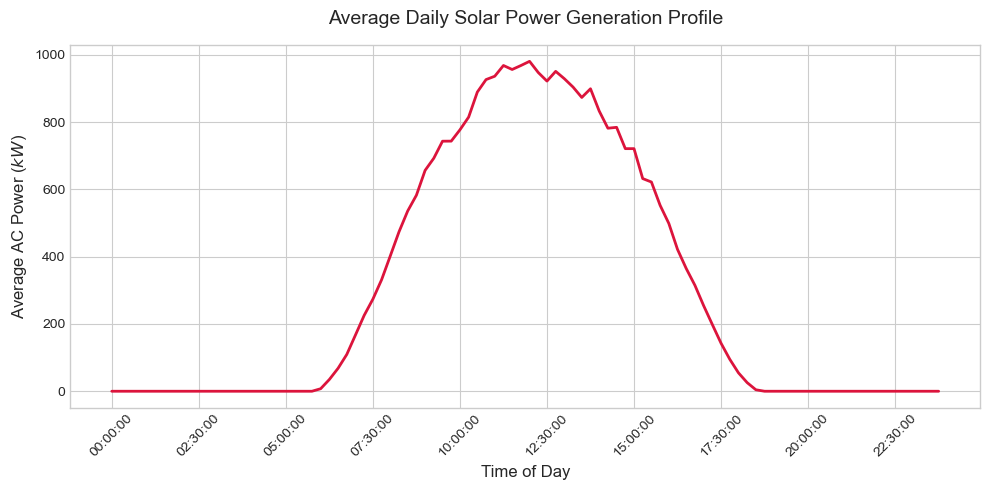

In [192]:
# Line Plot: Average Daily Profile (Checking the expected solar bell curve)
# Extract time for group aggregation
df_merged['TIME'] = df_merged['DATE_TIME'].dt.time
daily_profile = df_merged.groupby('TIME')['AC_POWER'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(daily_profile['TIME'].astype(str), daily_profile['AC_POWER'], color='crimson', linewidth=2)
plt.title('Average Daily Solar Power Generation Profile', fontsize=14, pad=15)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Average AC Power ($kW$)', fontsize=12)
plt.xticks(rotation=45)
# Reduce density of x-axis ticks for better readability
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(12))
plt.tight_layout()
plt.show()

### Interpretation: Average Daily Solar Power Generation Profile
The line chart displays the aggregated, average generation profile over a 24-hour cycle. 

* **Key Observation:** The plant shows zero power production from midnight until approximately $06:00\text{ AM}$. Production rapidly increases up with sunrise, forming a clean bell curve that peaks between $11:30\text{ AM}$ and $12:30\text{ PM}$ at just under $1000\text{ kW}$ of average AC power output. After noon, production smoothly decreases and hits zero again around $18:30\text{ PM}$ (6:30 PM).
* **Model Selection:** This strict day-night threshold is highly non-linear. A linear model assumes a constant, straight-line relationship and struggles with abrupt changes. A non-linear approach like the **Random Forest Regressor** can grasp this "on/off" physical constraint and trace the complex, curved shape of solar generation accurately. 
* **Trading Context:** Since this daily shape is easy to predict, traders can easily sell this power ahead of time. Knowing the precise timing of the morning ramp-up and evening drop-off helps them balance the power grid and react quickly to capture the best prices throughout the day.

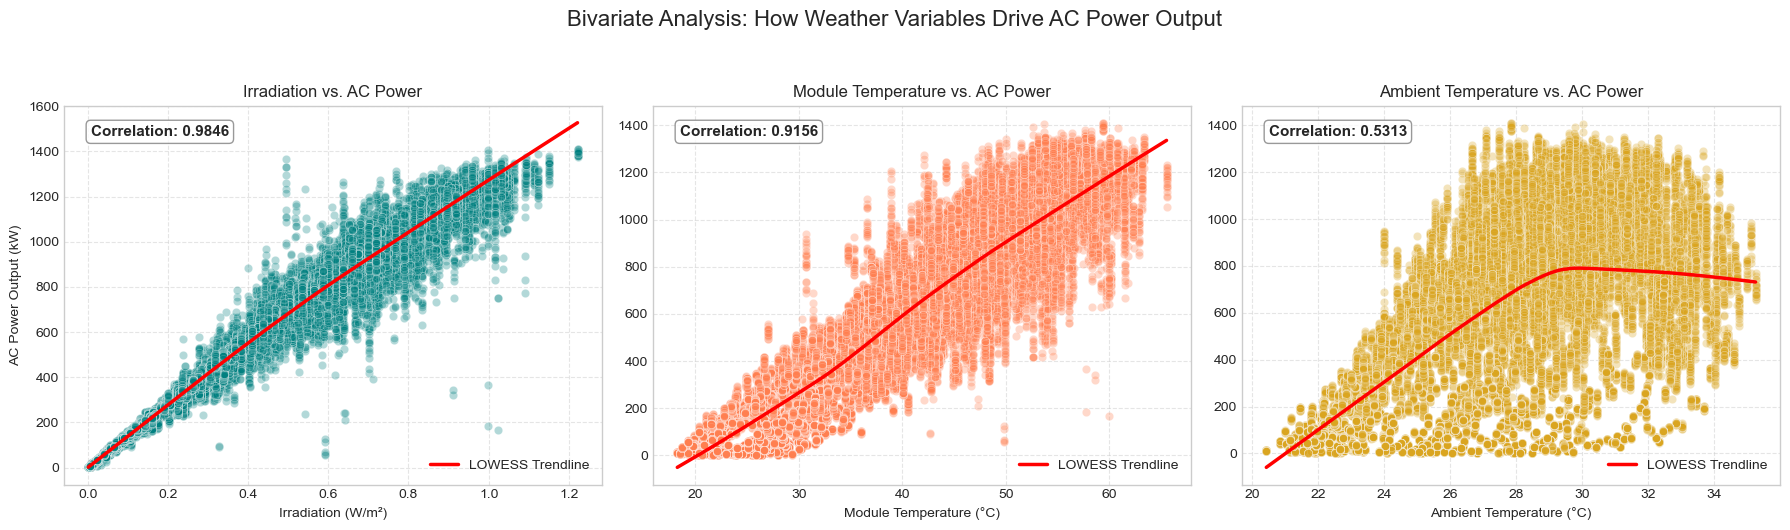

In [193]:
# Filter data for daytime (where AC_POWER > 0) to match the scatter plots
df_daytime = df_merged[df_merged['AC_POWER'] > 0]

# Calculate correlation coefficients
corr_irrad = df_daytime['IRRADIATION'].corr(df_daytime['AC_POWER'])
corr_mod_temp = df_daytime['MODULE_TEMPERATURE'].corr(df_daytime['AC_POWER'])
corr_amb_temp = df_daytime['AMBIENT_TEMPERATURE'].corr(df_daytime['AC_POWER'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Design for the text box
bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)

# Plot 1: Irradiation vs AC Power
sns.scatterplot(data=df_daytime, x='IRRADIATION', y='AC_POWER', alpha=0.3, ax=axes[0], color='teal')
sns.regplot(data=df_daytime, x='IRRADIATION', y='AC_POWER', scatter=False, lowess=True, ax=axes[0], 
            label='LOWESS Trendline', line_kws={'color': 'red', 'linewidth': 2.5})
axes[0].set_title('Irradiation vs. AC Power')
axes[0].set_xlabel('Irradiation (W/m²)')
axes[0].set_ylabel('AC Power Output (kW)')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].text(0.05, 0.92, f'Correlation: {corr_irrad:.4f}', transform=axes[0].transAxes, fontsize=11, fontweight='bold', bbox=bbox_props)
axes[0].legend(loc='lower right')

# Plot 2: Module Temperature vs AC Power
sns.scatterplot(data=df_daytime, x='MODULE_TEMPERATURE', y='AC_POWER', alpha=0.3, ax=axes[1], color='coral')
sns.regplot(data=df_daytime, x='MODULE_TEMPERATURE', y='AC_POWER', scatter=False, lowess=True, ax=axes[1], 
            label='LOWESS Trendline', line_kws={'color': 'red', 'linewidth': 2.5})
axes[1].set_title('Module Temperature vs. AC Power')
axes[1].set_xlabel('Module Temperature (°C)')
axes[1].set_ylabel('')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].text(0.05, 0.92, f'Correlation: {corr_mod_temp:.4f}', transform=axes[1].transAxes, fontsize=11, fontweight='bold', bbox=bbox_props)
axes[1].legend(loc='lower right')

# Plot 3: Ambient Temperature vs AC Power
sns.scatterplot(data=df_daytime, x='AMBIENT_TEMPERATURE', y='AC_POWER', alpha=0.3, ax=axes[2], color='goldenrod')
sns.regplot(data=df_daytime, x='AMBIENT_TEMPERATURE', y='AC_POWER', scatter=False, lowess=True, ax=axes[2], 
            label='LOWESS Trendline', line_kws={'color': 'red', 'linewidth': 2.5})
axes[2].set_title('Ambient Temperature vs. AC Power')
axes[2].set_xlabel('Ambient Temperature (°C)')
axes[2].set_ylabel('')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].text(0.05, 0.92, f'Correlation: {corr_amb_temp:.4f}', transform=axes[2].transAxes, fontsize=11, fontweight='bold', bbox=bbox_props)
axes[2].legend(loc='lower right')

plt.suptitle('Bivariate Analysis: How Weather Variables Drive AC Power Output', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Interpretation: How Weather Drivers Shape Solar Power Output

#### 1. Solar Irradiance
The first plot confirms that sunlight is the absolute primary driver of our plant, showing a near-perfect linear trend and an extremely high correlation coefficient of 0.9846. As solar irradiance increases, the electricity pumped into the grid rises proportionally, peaking around 1400 kW.
* **Operational Anomalies:** Interestingly, there is a flat horizontal line of data points sitting at exactly 0 kW even when the sun is shining brightly (between 0.2 and 1.2 W/m²). In the real world, this points to **operational issues** like inverter dropouts, sensor glitches, or temporary grid disconnections for maintenance. For a trading desk, spotting these patterns is important to manage risk and calculate potential imbalances.
* **Trading Insights:** This regular daily pattern shows how solar energy is bought and sold on the short-term electricity markets. Production stays at zero all night, increases sharply around 06:00 AM, and hits its highest point between 11:30 AM and 12:30 PM. Knowing the precise timing of this steep morning increase and evening decrease allows energy traders to keep the power grid stable and make a profit by selling electricity at the best possible times when prices change throughout the day.

#### 2. Temperature Interactions
* **Module Temperature:** With a strong correlation of 0.9156, module temperature shows a steady upward trend. The red LOWESS line runs almost perfectly straight through the data, confirming that as the solar panels heat up under the sun, the power output rises consistently alongside it. 
* **Ambient Temperature:** This plot provides the clearest evidence of non-linear behavior. The correlation drops significantly to 0.5313, and the shifting cloud of data points forms a distinct curve. The red LOWESS trendline climbs steadily at first, but upon reaching approximately 30°C, it completely flattens out and begins to bend downward. On hot afternoons, the actual power output varies wildly between 200 kW and 1400 kW.

### Conclusion for Model Selection
The plots prove that a standard Linear Regression would struggle with the overall weather data. A straight line cannot capture the distinct flattening and downward bend of the ambient temperature trendline above 30°C, nor can it handle the massive scattering caused by cloud cover. To prevent costly financial forecasting errors on the trading desk, we use a non-linear machine learning algorithm like a Random Forest Regressor, which easily maps these shifting curves and variations.

### Multicollinearity Analysis

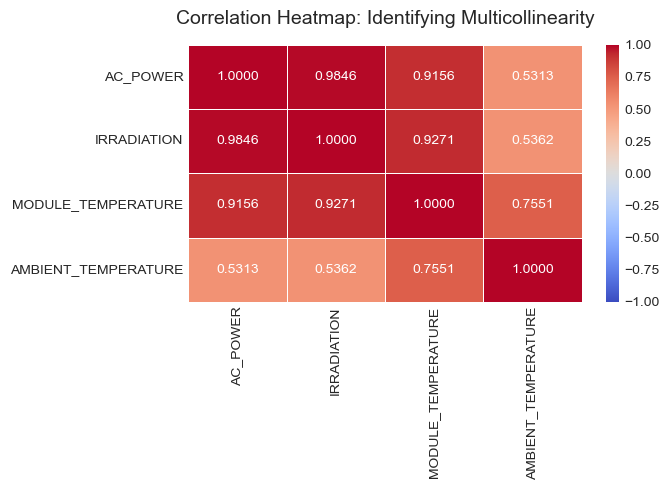

In [194]:
# We focus on the features used in the model (plus AC_POWER to see the targets)
features_to_check = [
    'AC_POWER', 'IRRADIATION', 'MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE']

# Calculate the correlation matrix for daytime data
corr_matrix = df_daytime[features_to_check].corr()

# Plot the heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.4f', 
    linewidths=0.5,
    vmin=-1, 
    vmax=1
)

plt.title('Correlation Heatmap: Identifying Multicollinearity', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### Interpretation: Correlation Matrix and Multicollinearity Analysis

The daytime correlation heatmap provides critical insights into the underlying relationships among our weather variables and the target, AC_POWER:

* **The Collinearity Issue:** There is a strong correlation of 0.9271 between IRRADIATION and MODULE_TEMPERATURE. This confirms severe multicollinearity. Because the solar panels heat up directly in response to sunlight, these two features carry nearly redundant information. 
* **The Air Temperature Bridge:** AMBIENT_TEMPERATURE shows a strong correlation with MODULE_TEMPERATURE (0.7551) but a much weaker direct correlation with IRRADIATION (0.5362). This highlights that air temperature behaves quite differently from the immediate heat absorbed by the panels themselves.

### Conclusion for Model
A tree-based ensemble method like Random Forest is a good choice as it solves both challenges at once: it handles correlated features effortlessly and maps the time component as well as the non-linear temperature curves without requiring complex manual transformations.

### Step 4: Feature Engineering 

In [195]:
# Extract time components for the model
df_merged['HOUR'] = df_merged['DATE_TIME'].dt.hour
df_merged['MINUTE'] = df_merged['DATE_TIME'].dt.minute  
df_merged['DAY'] = df_merged['DATE_TIME'].dt.day
df_merged['MONTH'] = df_merged['DATE_TIME'].dt.month

# Drop columns that are categorical IDs or redundant for the regression model
features_to_drop = ['DATE_TIME', 'PLANT_ID_gen', 'SOURCE_KEY_gen', 'PLANT_ID_weather', 'SOURCE_KEY_weather', 'TIME']
df_ml = df_merged.drop(columns=features_to_drop)

print("--- Prepared Features for Machine Learning ---")
display(df_ml.info())

df_ml.head()

--- Prepared Features for Machine Learning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68774 entries, 0 to 68773
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DC_POWER             68774 non-null  float64
 1   AC_POWER             68774 non-null  float64
 2   DAILY_YIELD          68774 non-null  float64
 3   TOTAL_YIELD          68774 non-null  float64
 4   AMBIENT_TEMPERATURE  68774 non-null  float64
 5   MODULE_TEMPERATURE   68774 non-null  float64
 6   IRRADIATION          68774 non-null  float64
 7   HOUR                 68774 non-null  int32  
 8   MINUTE               68774 non-null  int32  
 9   DAY                  68774 non-null  int32  
 10  MONTH                68774 non-null  int32  
dtypes: float64(7), int32(4)
memory usage: 4.7 MB


None

,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,MINUTE,DAY,MONTH
0,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0,0,0,15,5
1,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0,0,0,15,5
2,0.0,0.0,0.0,6987759.0,25.184316,22.857507,0.0,0,0,15,5
3,0.0,0.0,0.0,7602960.0,25.184316,22.857507,0.0,0,0,15,5
4,0.0,0.0,0.0,7158964.0,25.184316,22.857507,0.0,0,0,15,5


### Step 5: Base Model Comparison (Linear Regression vs. Random Forest)

In this step, we compare a **Linear Regression** model against a **Random Forest Regressor** to establish a solid baseline for our solar power forecast. 
* **Linear Regression** serves as the simplest statistical baseline, assuming a purely linear relationship between weather features (like irradiation and temperature) and power output.
* **Random Forest** is a non-linear, tree-based ensemble method capable of capturing complex interactions and thresholds in the data.

**Why we use a Random Split here:**
At this stage, our goal is to evaluate the models purely on their ability to map physical states (**Weather $\rightarrow$ Power Output**). Since we are not using any autoregressive or historical production features (like Lags) yet, each data point can be treated as an independent snapshot. A **random split (`shuffle=True`)** is the standard approach here because it ensures that both the training and testing sets receive an identical, well-balanced distribution of all seasons, weather conditions, and diurnal cycles (day/night phases) across the entire year.

=== BASE MODEL PERFORMANCE COMPARED ===
Linear Regression  -> R²: 0.9802 | MAE: 26.52 kW
Random Forest      -> R²: 0.9912 | MAE: 14.14 kW
--------------------------------------------------


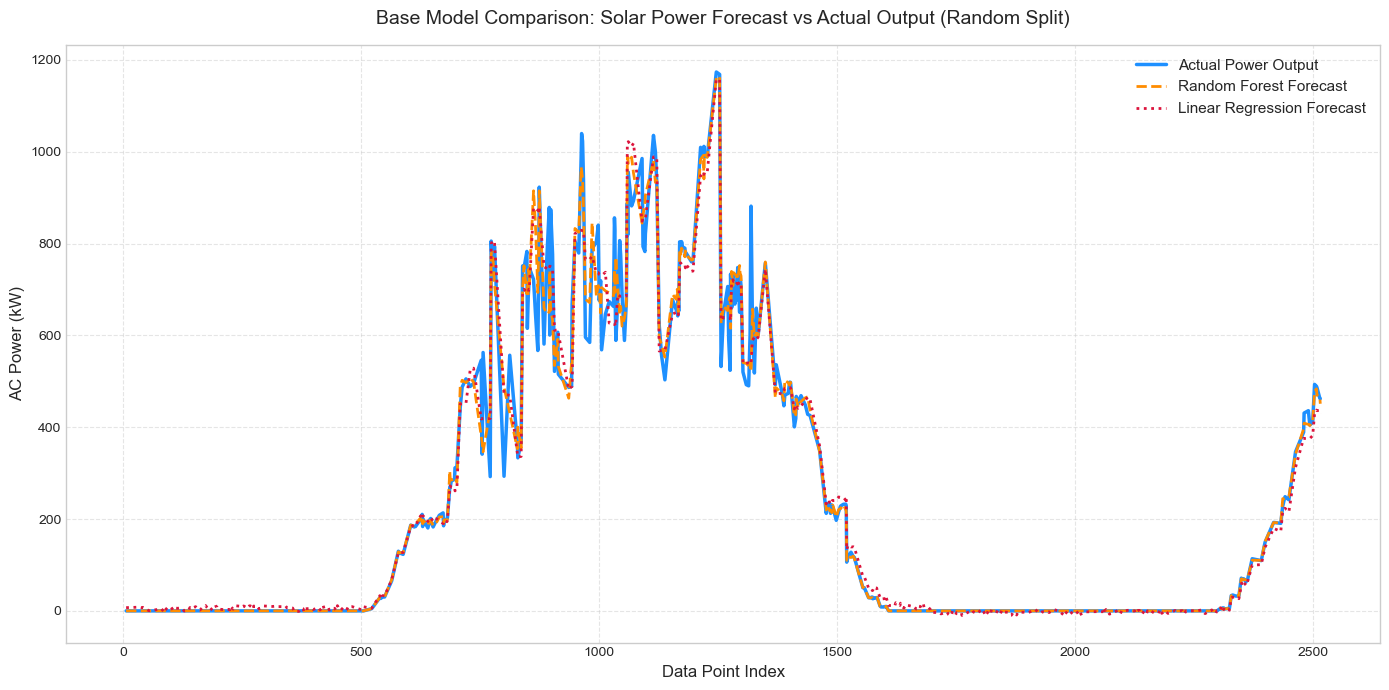

In [196]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Prepare Features and Target 
X_base = df_ml.drop(columns=['AC_POWER', 'DC_POWER']) # DC Power can be calculated from AC Power 
y_base = df_ml['AC_POWER']

# Random split 
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y_base, test_size=0.2, random_state=42, shuffle=True)

# 2. Train and Predict with Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_b, y_train_b)
y_pred_lr = lr_model.predict(X_test_b)

# 3. Train and Predict with Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_b, y_train_b)
y_pred_rf = rf_model.predict(X_test_b)

# 4. Calculate and Print Performance Metrics
r2_lr = r2_score(y_test_b, y_pred_lr)
mae_lr = mean_absolute_error(y_test_b, y_pred_lr)
r2_rf = r2_score(y_test_b, y_pred_rf)
mae_rf = mean_absolute_error(y_test_b, y_pred_rf)

print("=== BASE MODEL PERFORMANCE COMPARED ===")
print(f"Linear Regression  -> R²: {r2_lr:.4f} | MAE: {mae_lr:.2f} kW")
print(f"Random Forest      -> R²: {r2_rf:.4f} | MAE: {mae_rf:.2f} kW")
print("-" * 50)

# 5. Create Validation DataFrame and Plot 
df_results_base = pd.DataFrame({
    'Actual': y_test_b, 
    'Predicted_Linear': y_pred_lr,
    'Predicted_RandomForest': y_pred_rf
}).sort_index()

df_sample_base = df_results_base.head(500)

plt.figure(figsize=(14, 7))
plt.plot(df_sample_base.index, df_sample_base['Actual'], label='Actual Power Output', color='dodgerblue', linewidth=2.5)
plt.plot(df_sample_base.index, df_sample_base['Predicted_RandomForest'], label='Random Forest Forecast', color='darkorange', linestyle='--', linewidth=2)
plt.plot(df_sample_base.index, df_sample_base['Predicted_Linear'], label='Linear Regression Forecast', color='crimson', linestyle=':', linewidth=2)

plt.title('Base Model Comparison: Solar Power Forecast vs Actual Output (Random Split)', fontsize=14, pad=15)
plt.xlabel('Data Point Index', fontsize=12)
plt.ylabel('AC Power (kW)', fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Step 6: Autoregressive Time-Series Forecasting (Random Forest with Lag Features)

The previous setup successfully mapped static weather physics, but a real trading desk needs to catch sudden, short-term drops in power when clouds move in. To capture this time-dependent dynamic, we now transition into an **Autoregressive Time-Series approach** by adding **Lag Features** (`AC_POWER_LAG_1` to `_3`) based on what the plant actually produced over the last 45 minutes. Since the data points are now chronologically linked, we strictly switch to a **sequential split (`shuffle=False`)**. This mimics real-world trading conditions where you can only predict the future using the past, completely ruling out any data leakage.

RF WITHOUT Lags (Chronological Split) -> R²: 0.9766 | MAE: 18.47 kW
RF WITH Lags    (Chronological Split) -> R²: 0.9802 |MAE: 14.82 kW
--------------------------------------------------
Success! Lag features reduced the error by 3.65 kW!


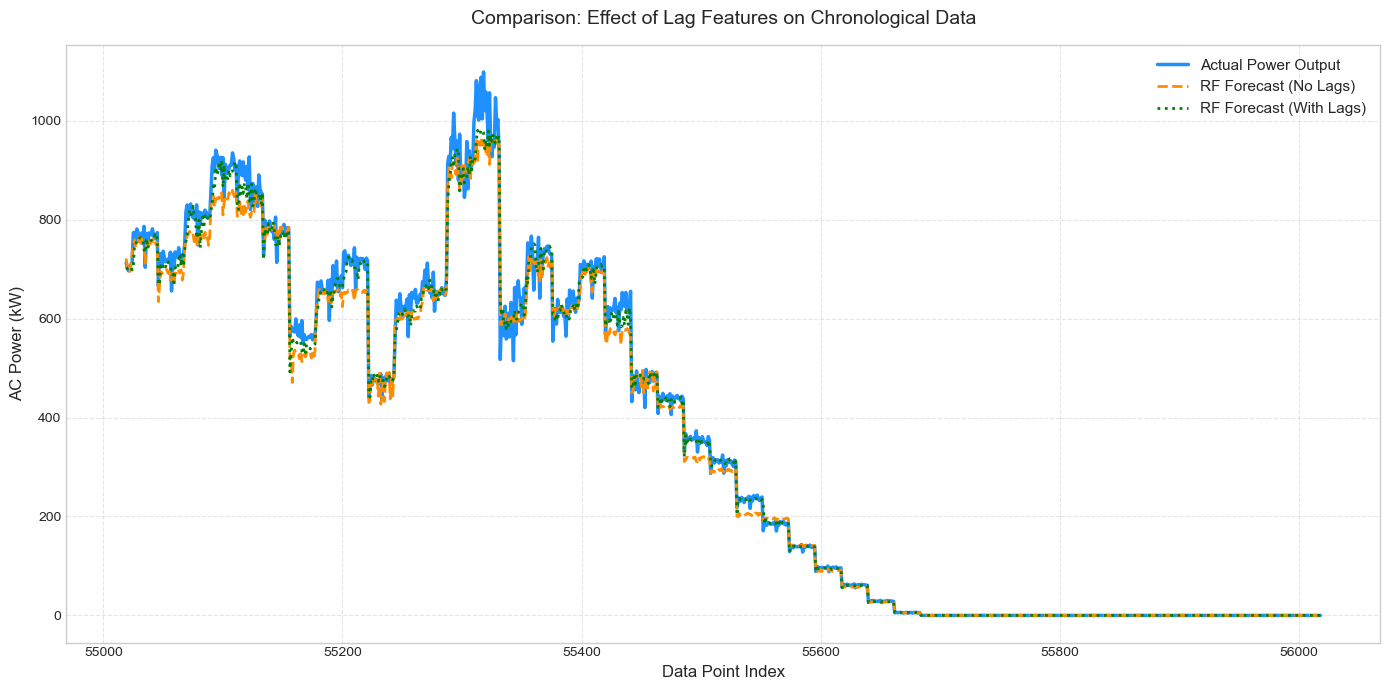

In [197]:
# 1. Feature Engineering: Create Lag Features
df_ml = df_ml.sort_index()
df_ml['AC_POWER_LAG_1'] = df_ml['AC_POWER'].shift(1)
df_ml['AC_POWER_LAG_2'] = df_ml['AC_POWER'].shift(2)
df_ml['AC_POWER_LAG_3'] = df_ml['AC_POWER'].shift(3)

# Drop rows with NaN values caused by shifting
df_ml_lagged = df_ml.dropna()

# 2. Setup Features for both models on the exact same split
# Model A Features (Classic: No Lags)
features_no_lags = [col for col in df_ml_lagged.columns if col not in ['AC_POWER', 'DC_POWER', 'AC_POWER_LAG_1', 'AC_POWER_LAG_2', 'AC_POWER_LAG_3']]
# Model B Features (Optimized: With Lags)
features_with_lags = [col for col in df_ml_lagged.columns if col not in ['AC_POWER', 'DC_POWER']]

y_lag = df_ml_lagged['AC_POWER']

# 3. Time-Series Train-Test Split (Chronological)
X_train_no, X_test_no, y_train, y_test = train_test_split(df_ml_lagged[features_no_lags], y_lag, test_size=0.2, shuffle=False)
X_train_with, X_test_with, _, _ = train_test_split(df_ml_lagged[features_with_lags], y_lag, test_size=0.2, shuffle=False)

# 4. Train Model A (Without Lags)
rf_no_lag = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_no_lag.fit(X_train_no, y_train)
y_pred_no_lag = rf_no_lag.predict(X_test_no)

# 5. Train Model B (With Lags)
rf_with_lag = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_with_lag.fit(X_train_with, y_train)
y_pred_with_lag = rf_with_lag.predict(X_test_with)

# 6. Compare Metrics on the same test set
r2_no = r2_score(y_test, y_pred_no_lag)
r2_with = r2_score(y_test, y_pred_with_lag)
mae_no = mean_absolute_error(y_test, y_pred_no_lag)
mae_with = mean_absolute_error(y_test, y_pred_with_lag)

print(f"RF WITHOUT Lags (Chronological Split) -> R²: {r2_no:.4f} | MAE: {mae_no:.2f} kW")
print(f"RF WITH Lags    (Chronological Split) -> R²: {r2_with:.4f} |MAE: {mae_with:.2f} kW")
print("-" * 50)
if mae_with < mae_no:
    print(f"Success! Lag features reduced the error by {mae_no - mae_with:.2f} kW!")
else:
    print("Check data structure. Lg features do not reduce error.")

# 7. Create Validation DataFrame and Plot (1000-point sample)
df_results_lag = pd.DataFrame({
    'Actual': y_test, 
    'Without_Lags': y_pred_no_lag,
    'With_Lags': y_pred_with_lag
}).sort_index()

df_sample_lag = df_results_lag.head(1000)

plt.figure(figsize=(14, 7))
plt.plot(df_sample_lag.index, df_sample_lag['Actual'], label='Actual Power Output', color='dodgerblue', linewidth=2.5)
plt.plot(df_sample_lag.index, df_sample_lag['Without_Lags'], label='RF Forecast (No Lags)', color='darkorange', linestyle='--', linewidth=2)
plt.plot(df_sample_lag.index, df_sample_lag['With_Lags'], label='RF Forecast (With Lags)', color='green', linestyle=':', linewidth=2)

plt.title('Comparison: Effect of Lag Features on Chronological Data', fontsize=14, pad=15)
plt.xlabel('Data Point Index', fontsize=12)
plt.ylabel('AC Power (kW)', fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Interpretation of Results and Validation Strategies

#### 1. Base Models (Random Split Evaluation)
* **Linear Regression:** Achieved an $R^2$ of **0.9802** and a Mean Absolute Error (MAE) of **26.52 kW**. While the high $R^2$ looks impressive, the linear model systematically struggles with volatile peaks and over- or underestimates production during rapid weather changes.
* **Random Forest (Base):** Outperformed the linear baseline clearly with an $R^2$ of **0.9912** and an MAE of **14.14 kW**. By capturing non-linear relationships, it maps the solar curve much more tightly.

#### 2. The Autoregressive Model (Chronological Split Evaluation)
When introducing **Lag Features** (`AC_POWER_LAG_1`, etc.) to capture sudden cloud movements, we strictly switched to a **chronological split (`shuffle=False`)** to prevent data leakage. 

The autoregressive Random Forest effectively models short-term volatility, catching sudden, sharp drops in power output (as seen in the zoomed-in green dotted line) much better than the static baseline. This directly leads to a significant MAE reduction of **3.65 kW**. 
While the $R^2$ values are slightly lower compared to the base models, this is because of the chronological split: the sequential test set focuses on a specific period with very low overall variance. Since $R^2$ is calculated relative to the variance of the test set, any minor deviation is penalised more heavily, making MAE the much more reliable source of truth.

**Conclusion for the Trading Desk:** In short, **Step 5** proves that our model has completely mastered the underlying **static physics** (Weather $\rightarrow$ Power), while **Step 6** proves its ability to capture the immediate **real-time trend** (Clouds $\rightarrow$ Volatility). This makes the **Autoregressive Random Forest with Chronological Splitting** the only viable setup for real-world Forecasting, as it successfully mimics real trading conditions without looking into the future.

### Future Outlook & Model Improvement Strategies

To further push the performance of our forecasting pipeline, the following iterative steps should be explored next:

1. **Cyclic Time Features:** Convert `HOUR` and `MINUTE` into Sine and Cosine components so the model mathematically understands that hour 23 and hour 0 are seamlessly connected.
2. **Rolling Window Statistics:** Introduce rolling features to give the model a smoother representation of recent production trends rather than relying solely on single lag snapshots.
3. **Advanced Algorithms:** Transition from Random Forest to Gradient Boosting architectures like **XGBoost** or **LightGBM**, which typically perform better at minimising MAE in volatile time-series datasets.